## The simplest possible autoencoder for Fashion MNIST 
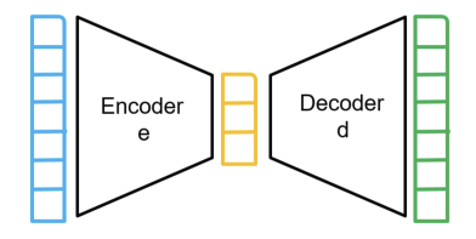


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
print('Done')

In [ ]:
# This is the size of our encoded representations
encoding_dim = 32  # 32 floats -> compression of factor 24.5, assuming the input is 784 floats

# This is our input image
input_img = keras.Input(shape=(784,)) # corresponds to 28x28
# "encoded" is the encoded representation of the input
encoded = layers.Dense(encoding_dim, activation='relu', name='encoder')(input_img)
# "decoded" is the lossy reconstruction of the input
decoded = layers.Dense(784, activation='sigmoid', name='decoder')(encoded)

# This model maps an input to its reconstruction
autoencoder = keras.Model(input_img, decoded, name="Autoencoder")
autoencoder.summary()

In [ ]:
#A seperated endoder
encoder = keras.Model(input_img, encoded, name="Encoder")
encoder.summary()

In [ ]:
# This is our encoded (32-dimensional) input
encoded_input = keras.Input(shape=(encoding_dim,))
# Retrieve the last layer of the autoencoder model
decoder_layer = autoencoder.layers[-1]
# Create the decoder model
decoder = keras.Model(encoded_input, decoder_layer(encoded_input), name="Decoder")
decoder.summary()

## Now train the model

In [ ]:
from keras.datasets import mnist
import numpy as np

## Import dataset MNIST-Fashion dataset
(x_train, _), (x_test, _) = keras.datasets.fashion_mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), -1)) # makes all sample 784 instead of 28,28,1
x_test = x_test.reshape((len(x_test), -1))
print(x_train.shape)
print(x_test.shape)


In [ ]:
#training sime should be less than a minute
#autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))


In [ ]:
# Use Matplotlib to create a function that vizualizes a comparision between original image , hidden representation &  and decoded
import matplotlib.pyplot as plt

def compare(original, encoded, decoded, n=10):
  plt.figure(figsize=(20, 6))
  for i in range(n):
    # Display original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(original[i].reshape(28, 28),cmap='binary')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Encoded pic
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(np.ones((32,32))*encoded[i], cmap='binary')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)


    # Display reconstruction
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded[i].reshape(28, 28),cmap='binary')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
  plt.show()




In [ ]:
# Encode and decode some digits
# Note that we take them from the *test* set
encoded_imgs = encoder.predict(x_test[:10])
decoded_imgs = decoder.predict(encoded_imgs)
compare(x_test, encoded_imgs, decoded_imgs, 10)

### Random variation in Latent space

Lets see if everything in the latent space makes sense.

In [ ]:
encoded_imgs = encoder.predict(x_test)

for i in range(10): # mirroring the byte vector
  np.random.shuffle(encoded_imgs[i])
decoded_imgs = decoder.predict(encoded_imgs)
compare(x_test, encoded_imgs, decoded_imgs, 10)